# ⚖️ 데이터 불균형 대처법 완전 정복

머신러닝 실무 현장에서 자주 부딪히는 문제 중 하나가 바로 **데이터 불균형(Data Imbalance)** 문제입니다.

타겟 데이터의 클래스 비율이 불평등하게 왜곡되어 있으면 모델이 대다수 클래스로 편향되어 예측하는 심각한 성능 저하가 발생합니다.

이번 복습 노트에서는 데이터 불균형의 주요 원인부터 **언더샘플링(UnderSampling)**, **오버샘플링(OverSampling)** 기법들의 작동 원리와 `imbalanced-learn` 라이브러리를 활용한 실전 코드를 완벽하게 정리해 봅니다.

---

## 📌 데이터 불균형과 전처리 개요

* **데이터 불균형이란?**
  - 추론하고자 하는 특정 클래스(타겟)의 데이터 수가 다른 클래스에 비해 현저히 적거나 많은 분포 상태를 의미. (예: 희귀 질환 진단 등)

* **문제점**
  - 모델이 단순히 데이터 수가 많은 클래스만 맞추도록 학습되어, 중요한 희소 클래스에 대한 예측력을 잃고 과적합(Overfitting)되는 문제 발생.

---

### 💡 참고: 결측치와 이상치 처리 방법

데이터 불균형을 다루기 전, 데이터 전처리 단계에서 결측치와 이상치를 정제하는 대표적인 방법도 함께 정리해 둡시다.

* **결측치(Missing Value) 처리 종류**:
  * **수집**: 추가 데이터를 수집하여 결측값 채우기
  * **대체**: 평균값, 중앙값, 최빈값, KNN 등의 대치 알고리즘을 사용해 결측값 채우기
  * **제거**: 결측치가 존재하는 행(Row)이나 열(Column)을 완전히 제거하기


* **이상치(Outlier) 처리 종류**:
  * **변수화**: 이상치를 범주형(Categorical) 구간으로 변환하여 유의미한 수치 범위로 재구성하기
  * **대체**: 상한값/하한값(Capping) 또는 대표 수치로 대체하기
  * **제거**: 도메인 기준 또는 IQR/Z-Score 기준을 벗어난 이상치 행 제거하기



---

## 1. UnderSampling (언더샘플링)

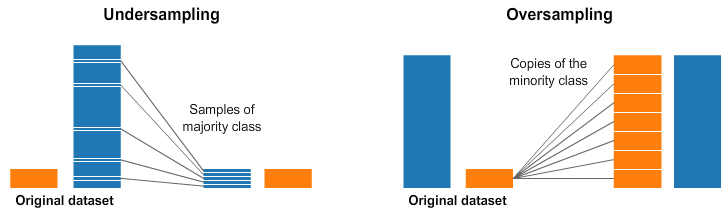

언더샘플링은 **수가 더 많은 대다수 클래스의 데이터를 삭제**하여 희소 클래스와 수 비율을 일치시키는 기법입니다.

* **장점**: 데이터 크기가 감소하여 모델 학습 시간이 대폭 줄어듭니다.
* **단점**: 대다수 클래스의 중요한 정보나 유용한 패턴이 삭제되어 정보 손실이 발생할 수 있습니다.
* **적용 시점**: 전체 데이터 수가 충분히 많은 상황일 때 주로 사용됩니다.

### 1-1. Random Sampling
* **원리**: 수가 많은 클래스에서 무작위(Random)로 샘플을 추출해 삭제하여, 희소 클래스의 개수만큼 비율을 줄여 일치시킵니다.
* **특징**: 단순하지만 유용한 데이터까지 무작위로 삭제될 수 있다는 단점이 있습니다.

### 1-2. Tomek Links

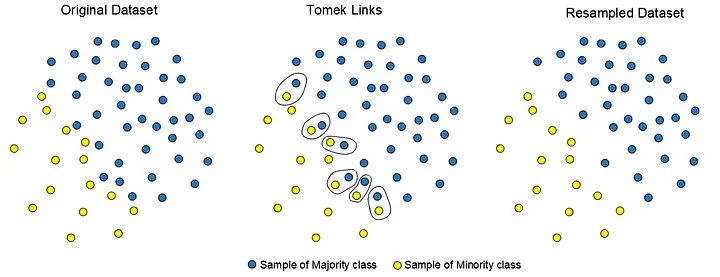

* **원리**: 서로 다른 클래스에 속하면서 가장 근접해 있는 한 쌍의 데이터 포인트를 찾은 후, 그중 대다수 클래스의 데이터 포인트를 삭제합니다.
* **특징**: 경계선 부근의 모호한 대다수 데이터를 제거하므로 **데이터 간의 분류 경계선(Boundary)을 더 명확하게** 정돈해 줍니다.
* **주의**: 데이터셋 크기가 매우 크면 최단 거리를 계산하는 시간이 많이 소요됩니다.

### 1-3. CNN rule (Condensed Nearest Neighbor)

* **원리**: 희소 클래스 데이터 전체와 근접한 대다수 클래스 샘플만 선택하여 추출합니다.
* **특징**: 분류 경계 근처의 핵심 샘플들을 유지하여 전체 데이터의 주요 구조와 패턴을 효과적으로 보존합니다.

In [ ]:
import pandas as pd
from sklearn.datasets import make_classification
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, CondensedNearestNeighbour

# 1. 가상의 불균형 와인 데이터 생성 (예시)
X_dummy, y_dummy = make_classification(n_samples=1000, n_features=5, weights=[0.9, 0.1], random_state=42)
wine = pd.DataFrame(X_dummy, columns=['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides'])
wine['quality'] = y_dummy

# 데이터 전처리
features = wine.columns.drop('quality')
X = wine[features]
y = wine['quality']

# 2. RandomUnderSampler
sampler_rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = sampler_rus.fit_resample(X, y)

# 3. Tomek Links
sampler_tomek = TomekLinks()
X_tomek, y_tomek = sampler_tomek.fit_resample(X, y)

# 4. CNN rule
sampler_cnn = CondensedNearestNeighbour(random_state=42)
X_cnn, y_cnn = sampler_cnn.fit_resample(X, y)

---

## 2. OverSampling (오버샘플링)

오버샘플링은 **수가 더 적은 희소 클래스 데이터를 복제하거나 합성 생성**하여 대다수 클래스와 수 비율을 일치시키는 기법입니다.

* **장점**: 원본 데이터의 정보를 단 하나도 손실시키지 않고 유지할 수 있습니다.
* **단점**: 데이터를 늘리는 과정에서 과적합(Overfitting) 위험이 높아지거나 계산 비용이 늘어날 수 있습니다.
* **적용 시점**: 전체 데이터 수가 절대적으로 부족한 상황일 때 주로 사용됩니다.

### 2-1. Resampling

* **원리**: 소수 클래스의 데이터를 무작위로 선택하여 그대로 복제함으로써 대다수 클래스 양만큼 수를 맞춥니다.
* **특징**: 구현이 쉽지만, 동일한 데이터를 단순 반복 복제하므로 과적합 위험성이 매우 높습니다.

### 2-2. SMOTE (Synthetic Minority Over-sampling Technique)

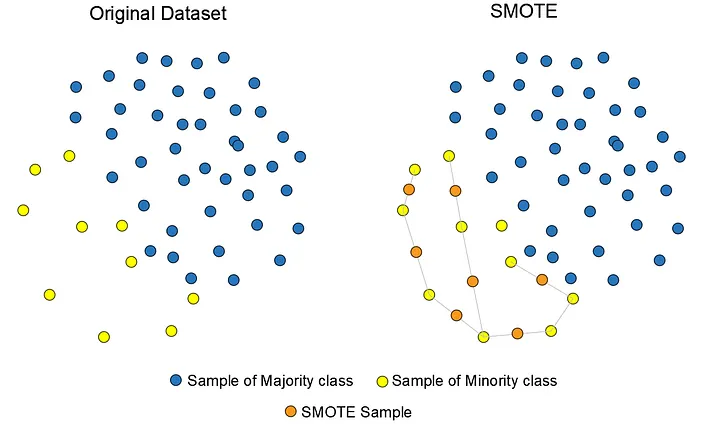

* **원리**: 소수 클래스 데이터에 **KNN** 알고리즘을 적용, 가깝게 인접한 데이터 포인트 사이의 선분 상에 새로운 합성 데이터를 생성합니다.
* **장점**: 단순 복제가 아닌 완전히 새로운 데이터를 합성하므로 과적합 문제를 상당 부분 완화합니다.
* **주의**: 무작위 선분 상에서 데이터를 만들다 보니, 새로 생성된 데이터가 기존 데이터의 실제 분포 형태와 살짝 다를 수 있습니다.

### 2-3. Borderline SMOTE

* **원리**: 소수 클래스 데이터 중에서도 **대다수 클래스와 접해 있는 경계 영역(Borderline)에 위치한 데이터**들에 집중해서 SMOTE를 적용합니다.
* **장점**: 모델이 결정 경계(Decision Boundary) 부근의 애매한 데이터를 더 원활하게 구분할 수 있도록 돕습니다.
* **주의**: 경계 주변의 노이즈 데이터까지 함께 증폭시킬 위험이 있습니다.

In [ ]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE

# 1. Resampling (RandomOverSampler)
sampler_ros = RandomOverSampler(random_state=42)
X_ros, y_ros = sampler_ros.fit_resample(X, y)

# 2. SMOTE
sampler_smote = SMOTE(k_neighbors=4, random_state=42)
X_smote, y_smote = sampler_smote.fit_resample(X, y)

# 3. Borderline SMOTE
sampler_bsmote = BorderlineSMOTE(k_neighbors=4, random_state=42)
X_bsmote, y_bsmote = sampler_bsmote.fit_resample(X, y)

---

## 📝 핵심 요약 가이드

| 구분 | 대표 기법 | 핵심 개념 및 특징 | 적용 권장 상황 |
| --- | --- | --- | --- |
| **UnderSampling** | `RandomUnderSampler` | 대다수 클래스 무작위 제거 | 전체 데이터 양이 충분히 많을 때 |
|  | `TomekLinks` | 경계 부근 다수 데이터 제거로 경계 명확화 | 분류 경계를 깨끗이 정리하고 싶을 때 |
|  | `CondensedNearestNeighbour` | 주요 구조 보존하며 경계 샘플 위주 선택 | 구조 손실을 최소화하고 싶을 때 |
| **OverSampling** | `RandomOverSampler` | 희소 클래스 무작위 복제 | 구현이 단순하나 과적합 위험 높음 |
|  | `SMOTE` | KNN 기반 보간으로 가상 데이터 합성 생성 | 정보 손실 없이 과적합을 방지할 때 |
|  | `BorderlineSMOTE` | 경계선 부근 희소 데이터에 집중 SMOTE | 결정 경계 부근 식별력을 향상시킬 때 |


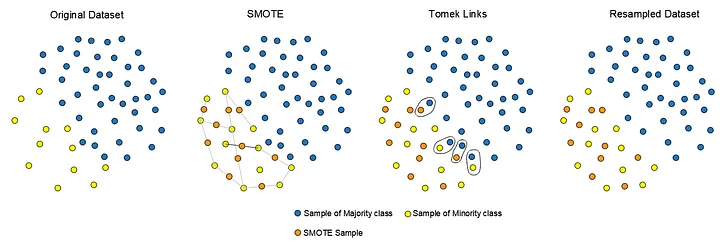